In [166]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Loading the data
To get started let's first load in the data! We will make use of the helper functions provided in `data_utils.py`

In [167]:
from data_utils import get_images, get_labels

The following is the list of disasters in our dataset. 

In [168]:
disaster_list = ["socal-fire", "midwest-flooding"]

We will load each disaster train dataset into a dictionary. Recall that each disaster consists of images and labels (0 - 3) of the damage level.

In [169]:
data = {}
split = "train"
with open('config.json') as config_file:
    config = json.load(config_file)
    data_dir = config['data_dir']

for disaster in disaster_list:
    print(f"Loading {split} images and labels for {disaster} dataset...")
    images = get_images(data_dir, disaster, split=split)
    labels = get_labels(data_dir, disaster, split=split)
    data[disaster] = {"images": images, "labels": labels}

Loading train images and labels for socal-fire dataset...
Loading train images and labels for midwest-flooding dataset...


Let's visualize an image and its label in the dataset. 

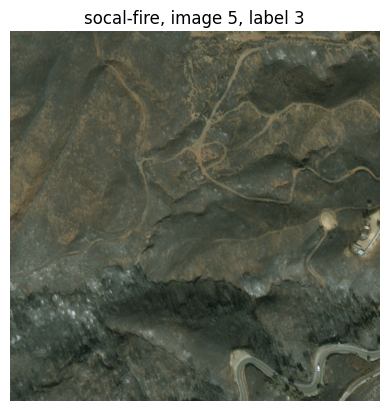

image shape: (1024, 1024, 3)


In [170]:
disaster = disaster_list[0]
images = data[disaster]["images"]
labels = data[disaster]["labels"]

# index of the image to display
idx = 5
img = images[idx]
label = labels[idx]

plt.title(f"{disaster}, image {idx}, label {label}")
plt.imshow(img.astype(np.uint8))
plt.axis("off")
plt.show()

#
print(f"image shape: {img.shape}")

# Extracting Color Information
Each image is an RGB image represented as a numpy array of dimensions (width, height, 3). The last dimension corresponds to the RGB *color channels* in the image. We can split the image by color channels and visualize each of them individually.

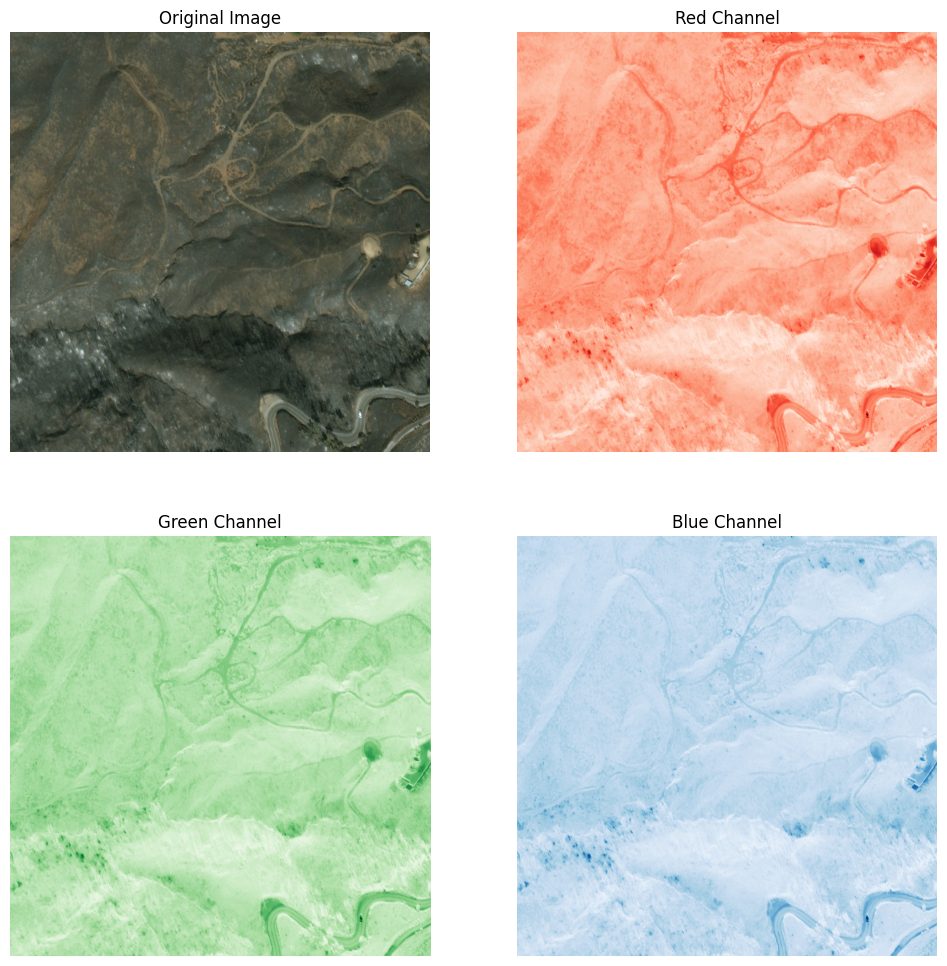

In [171]:
plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(img[:, :, 0], cmap="Reds", vmin=0, vmax=255)
plt.title("Red Channel")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(img[:, :, 1], cmap="Greens", vmin=0, vmax=255)
plt.title("Green Channel")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img[:, :, 2], cmap="Blues", vmin=0, vmax=255)
plt.title("Blue Channel")
plt.axis("off")

plt.show()

We can zoom in on just a pixel as well.

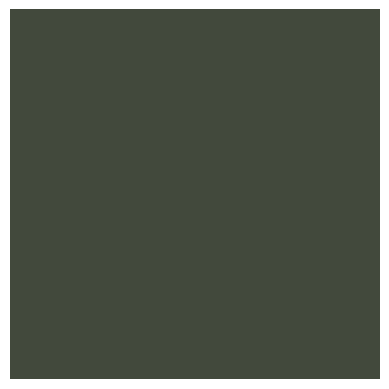

Pixel value: [66 73 60], coordinate: (15, 35)


In [172]:
coord = (15, 35)
pixel_value = img[coord[0], coord[1], :]
pixel_image = np.array([[pixel_value]])

plt.imshow(pixel_image)
plt.axis("off")
plt.show()

print(f"Pixel value: {pixel_value}, coordinate: {coord}")

# Extracting Edge and Texture Information

So far we have considered the **color** information in an image. However, other important aspects of an image are the edges and texture. 

Let us consider some popular feature processing methods for extracting edge and texture information. We will use the utilities provided in `feature_utils.py`.

In [173]:
from feature_utils import get_sobel_features, get_gabor_features, generate_gabor_kernel, get_local_binary_pattern

Let's try the Sobel Edge Filter. 

Read more about Sobel edge detection: https://en.wikipedia.org/wiki/Sobel_operator and https://scikit-image.org/docs/stable/auto_examples/edges/plot_edge_filter.html

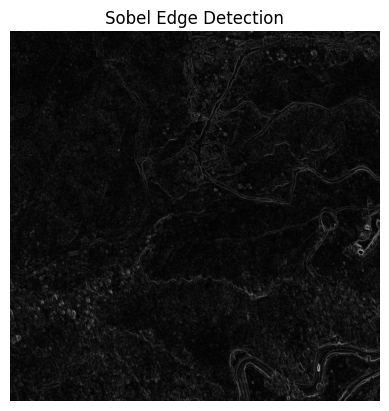

In [174]:
edges = get_sobel_features(img)
plt.imshow(edges, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")
plt.show()

Now let's look at local binary patterns. 

Read more about LBP: https://en.wikipedia.org/wiki/Local_binary_patterns and https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_local_binary_pattern.html

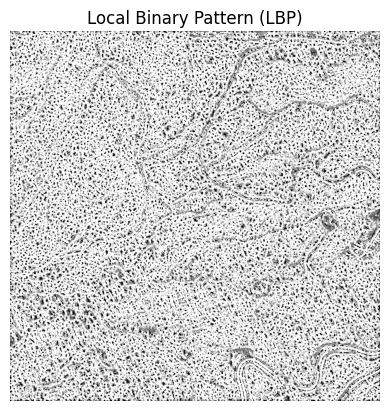

In [175]:
lbp = get_local_binary_pattern(img, radius=5)
plt.imshow(lbp, cmap="gray")
plt.axis("off")
plt.title("Local Binary Pattern (LBP)")
plt.show()

(array([108607.,  31761.,  22364.,  21738.,  29735.,  26642.,  18362.,
         18842.,  29673., 740852.]),
 array([ 0. ,  4.1,  8.2, 12.3, 16.4, 20.5, 24.6, 28.7, 32.8, 36.9, 41. ]),
 <BarContainer object of 10 artists>)

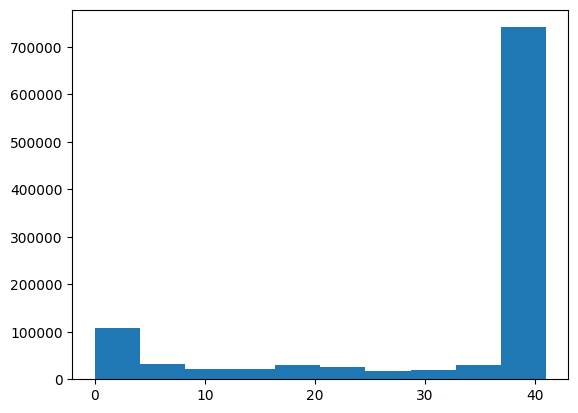

In [176]:
bins = np.linspace(0, 41, 20)
plt.hist(lbp.ravel())

Another popular filter for image processing is the Gabor filter. The Gabor filters are a family of filters parametrized by orientation, frequency, bandwith, etc. Let's generate one such filter.

Read more about Gabor filters: https://en.wikipedia.org/wiki/Gabor_filter and https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_gabor.html

In [177]:
theta = 0
sigma = 6
frequency = 0.02

kernel = generate_gabor_kernel(theta, sigma, frequency)
gabor = get_gabor_features(img, kernel)

Let's visualize this filter (aka kernel) and the response of the image when we apply the filter. Concretely we are taking the convolution of the image with the filter. See https://en.wikipedia.org/wiki/Kernel_(image_processing) for more details.

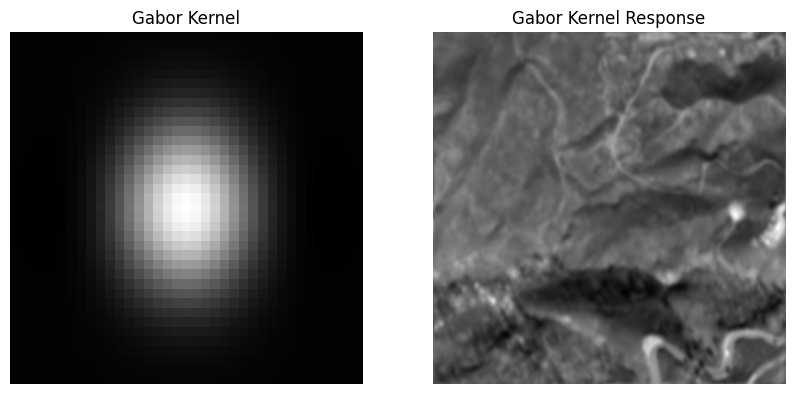

In [178]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Plot Gabor Kernel
axs[0].imshow(kernel, cmap="gray")
axs[0].axis("off")  # Remove axis
axs[0].set_title("Gabor Kernel")

# Plot Gabor Kernel Response
axs[1].imshow(gabor, cmap="gray")
axs[1].axis("off")  # Remove axis
axs[1].set_title("Gabor Kernel Response")

plt.show()

# Exploratory Data Analysis

The agency would like you to start performing some exploratory data analysis to build an initial understanding of the data. As part of the exploratory data analysis, the agency is interested in understanding certain aspects of the dataset better. 

Feel free to add more cells as you see fit for your analysis. 

# EDA - Basic Statistics

## Number of Images per Disaster Type


In [179]:
for disaster, disaster_data in data.items():
    print(f"{disaster} - {len(disaster_data['images'])} images")

socal-fire - 200 images
midwest-flooding - 200 images


## Distribution of Image Sizes in Each Dataset

We can compute the average, max, and min size of each image by dataset.

In [ ]:
disaster_image_shapes = {}
for disaster, disaster_data in data.items():
    width, height, _ = zip(*map(lambda img: img.shape, disaster_data['images']))
    disaster_image_shapes[disaster] = {'width_dist': width, 'height_dist': height}
    print(f"{disaster}\n\taverage -- width: {np.mean(width)} - height: {np.mean(height)}\n\tmax -- width: {np.max(width)} - height: {np.max(height)}\n\tmin -- width: {np.min(width)} - height: {np.min(height)}")

socal-fire
	average -- width: 1024.0 - height: 1024.0
	max -- width: 1024 - height: 1024
	min -- width: 1024 - height: 1024
midwest-flooding
	average -- width: 1024.0 - height: 1024.0
	max -- width: 1024 - height: 1024
	min -- width: 1024 - height: 1024


From the above, we see each image is the same size across datasets.

### Note - Tiling Effects and Image Size

It would appear that while the images are the same sizes, this is due in part to them being resized with a black tiling effect. For example, check out image 24 from the socal fire dataset.

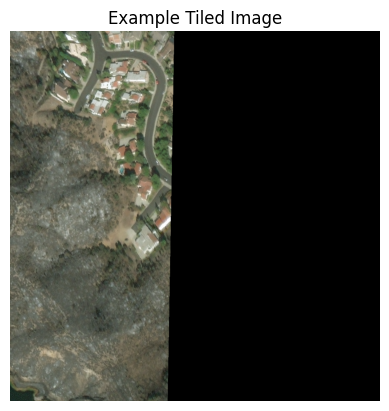

In [181]:
socal_24 = data['socal-fire']['images'][24]#[37]
plt.imshow(socal_24)
plt.axis("off")
plt.title("Example Tiled Image")
plt.show()

To address this, we developed a function to perform a rectangular crop of the image to minimize the black portion.

In [ ]:
def crop_image(img):
    crop = np.argwhere(np.sum(img, axis=2) != 0)
    x_min, x_max = np.min(crop[:, 0]), np.max(crop[:, 0])
    y_min, y_max = np.min(crop[:, 1]), np.max(crop[:, 1])
    return img[x_min:x_max, y_min:y_max]

This is what the previous image looks like when cropped.

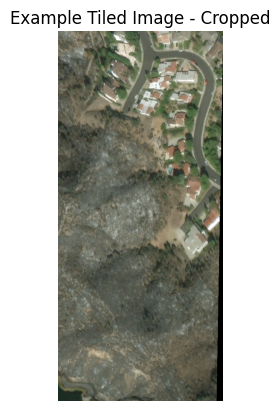

In [183]:
plt.imshow(crop_image(socal_24))
plt.axis("off")
plt.title("Example Tiled Image - Cropped")
plt.show()

Let's get some baseline statistics on how prevalent this tiling is on images from each dataset

In [184]:
def has_tiling(image):
    return np.any(np.sum(image, axis=2) == 0)

print("socal fire tiling fraction: ")
print(f"{np.mean(list(map(has_tiling, data['socal-fire']['images']))):.1%}")

print("midwest flooding tiling fraction: ")
print(f"{np.mean(list(map(has_tiling, data['midwest-flooding']['images']))):.1%}")

socal fire tiling fraction: 
23.0%
midwest flooding tiling fraction: 
16.0%


In [ ]:
disaster_image_shapes_cropped = {}
for disaster, disaster_data in data.items():
    width, height, _ = zip(*map(lambda img: crop_image(img).shape, disaster_data['images']))
    disaster_image_shapes[disaster] = {'width_dist': width, 'height_dist': height}
    print(f"{disaster}\n\taverage -- width: {np.mean(width)} - height: {np.mean(height)}\n\tmax -- width: {np.max(width)} - height: {np.max(height)}\n\tmin -- width: {np.min(width)} - height: {np.min(height)}")

## Distribution of Damage Labels

# EDA - Useful Image Features for Classification

The agency is looking for insights into useful image features for classifying images based on disaster type or damage level. You are tasked with verifying this and exploring whether color, edge, or texture features can effectively differentiate:

1. `midwest-flooding` from `socal-fire` images.
2. Damage levels 1 and 3 within the `hurricane-matthew` dataset.

Previous interns have found color information to be potentially useful.

## Distribution of Color (RGB)

In [185]:
# Helper function to compute average rgb of an image
def compute_average_rgb(image: np.ndarray):
    # Remove black pixels from tiling effect
    non_black_pixels = np.sum(np.einsum('ijk->ij', image > 0))

    # Return average image pixel rgb values
    return np.einsum('ijk->k', image.astype(int))/(non_black_pixels)

In [186]:
rgb_distribution = {}
for disaster, disaster_data in data.items():
    average_colors = [compute_average_rgb(image) for image in data[disaster]['images']]
    rgb_distribution[disaster] = list(zip(*average_colors))

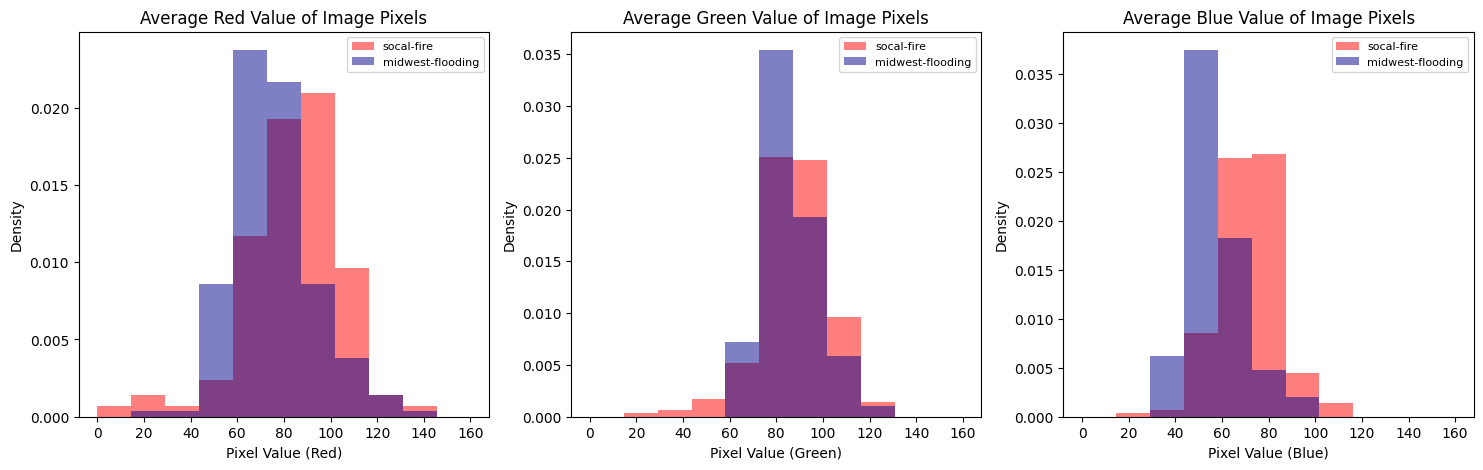

In [187]:
fig, axes = plt.subplots(1,3, dpi=100)
fig.set_figheight(5)
fig.set_figwidth(18)

axes = axes.flatten()

for disaster, distribution in rgb_distribution.items():
    for i in range(3):
        color = ['Red', 'Green', 'Blue'][i]
        ax = axes[i]
        # Plot histogram of color
        ax.hist(
            distribution[i],
            bins = np.linspace(0, 160, 12),
            label=disaster,
            alpha=0.5,
            density=True,
            color='red' if disaster=='socal-fire' else 'darkblue'
        )
        ax.set_xlabel(f"Pixel Value ({color})")
        ax.set_ylabel(f"Density")
        ax.set_title(f"Average {color} Value of Image Pixels", fontsize=12)
        ax.legend(fontsize=8);

## How are the distributions "separable"?

The below are a non-exhaustive list of ways we can think about classifying these disaster images. You do not have to include all of them in your analysis.

### 1. `midwest-flooding` vs `socal-fire`

Among the different disaster events, are there are distinctions in:

- image height, width, or overall size?
- RGB values?
- Sobel edges?
- Local Binary Patterns?
- Gabor kernels?



#### Image Size

It would seem both sets of images have been manipulated to be the same shape and size. This helpful for image manipulation down the line. However, we will need to take care to ensure that the black tiling effect is accounted for if present.

#### Gabor Kernels

In [212]:
from tqdm import tqdm
from joblib import Parallel, delayed
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from scipy.spatial.distance import pdist

In [189]:
def get_gabor_aggregate_features(image, kernel):
    gabor_filtered_image = get_gabor_features(image, kernel)
    var = np.var(gabor_filtered_image)
    mean = np.mean(gabor_filtered_image)
    return mean, var

def get_encoded_gabor_features(image, kernels) -> np.ndarray:
    feats = np.empty((len(kernels), 2), dtype=float)
    for i, kernel in enumerate(kernels):
        feats[i, 0], feats[i, 1] = get_gabor_aggregate_features(image, kernel)
    return feats

In [190]:
kernels = []
for theta in range(4):
    theta = theta / 4.0 * np.pi
    for sigma in (1, 5):
        for frequency in (0.05, 0.25):
            kernel = generate_gabor_kernel(theta=theta, sigma=sigma, frequency=frequency)
            kernels.append(kernel)

In [193]:
def get_features(image, disaster):
    return get_encoded_gabor_features(crop_image(image), kernels).flatten(), disaster

In [194]:
gabor_filter_feature_list = []
gabor_filter_label_list = []
for disaster, disaster_data in data.items():
    parallel = Parallel(n_jobs=6, return_as="generator")
    for features, disaster in tqdm(parallel(delayed(get_features)(image, disaster) for image in disaster_data['images']), total=200):
        gabor_filter_feature_list.append(features)
        gabor_filter_label_list.append(disaster)
    
y, X = np.array(gabor_filter_label_list), np.vstack(gabor_filter_feature_list)
    
y, X = np.array(gabor_filter_label_list), np.vstack(gabor_filter_feature_list)

100%|██████████| 200/200 [05:00<00:00,  1.50s/it]


In [195]:
scaler = RobustScaler()
gabor_pca = PCA(2)
scaled_pca = PCA(0.9)

visualization = gabor_pca.fit_transform(X)

scaled_X = scaler.fit_transform(X)
scaled_visualization = scaled_pca.fit_transform(scaled_X)

In [229]:
scaled_visualization[:, 0:2]

array([[-2.67940466e+00, -9.64527776e-01],
       [-3.13661024e+00,  2.36784423e-01],
       [ 1.78932168e+00, -1.40772171e+00],
       [-3.38564083e+00, -7.71923281e-01],
       [-1.29433054e+01,  2.00652253e+00],
       [-2.68551256e+00, -8.05948599e-01],
       [-8.42103592e-02, -1.45850046e+00],
       [ 3.20021897e+00, -1.96256653e+00],
       [ 2.55182067e+00, -1.98197366e+00],
       [-3.18945137e+00, -5.85439281e-01],
       [-7.95794763e-02, -1.10676734e+00],
       [ 2.57840800e+00, -1.72130210e+00],
       [-3.46405783e+00, -8.05634972e-01],
       [-3.04962770e+00, -6.90543892e-01],
       [-1.91405757e+00, -1.27143888e-01],
       [ 1.42929114e+00,  6.81394404e-01],
       [-4.05078931e+00, -8.28627614e-01],
       [ 2.01004387e+00, -1.92947863e+00],
       [ 3.18374948e-01, -1.64222708e+00],
       [ 2.06131915e+00, -1.43787153e+00],
       [ 5.59490801e-01, -1.58950738e+00],
       [-4.20832729e+00, -9.03248479e-01],
       [ 2.66298910e+00, -2.21669572e+00],
       [ 1.

In [230]:
lr_model = LogisticRegression(fit_intercept=True)
lr_model.fit(scaled_visualization[:, 0:2], y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [240]:
y_value = (lr_model.coef_[0][0] * line_samples - lr_model.intercept_[0]) / lr_model.coef_[0][1]

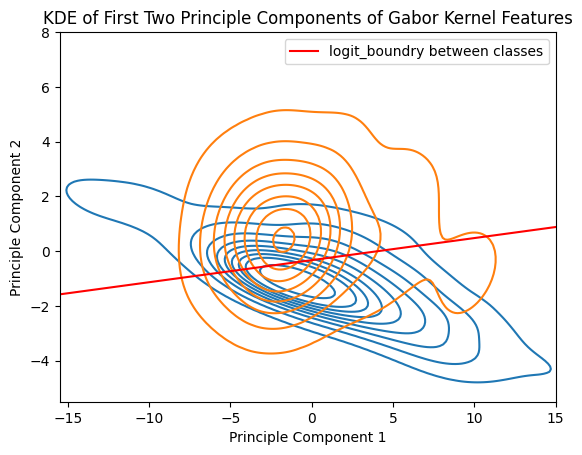

In [243]:
sns.kdeplot(
    data=pd.DataFrame(scaled_visualization, columns=["Principle Component 1", "Principle Component 2", "Principle Component 3", "Principle Component 4"]),
    x="Principle Component 1",
    y="Principle Component 2",
    hue=y,
)

line_samples = np.linspace(-15.5, 15, 200)
y_value = (lr_model.coef_[0][0] * line_samples - lr_model.intercept_[0]) / lr_model.coef_[0][1]
plt.plot(line_samples, y_value, color='red', label='logit_boundry between classes')
plt.xlim((-15.5, 15))
plt.ylim((-5.5, 8))
plt.legend()
plt.title('KDE of First Two Principle Components of Gabor Kernel Features');

In [232]:
lr_model.coef_

array([[-0.13484092, -1.67194574]])

In [233]:
lr_model.intercept_

array([-0.549536])

In [222]:
lr_model.score(scaled_visualization[:, 0:2], y)

0.8275

In [210]:
lr_model?

Type:        LogisticRegression
String form: LogisticRegression()
File:        ~/Documents/msse/fall_2025/data-200S/satellite-image-classification-project/.image_classification_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py
Docstring:  
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using the
'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
that regularization is applied by default**. It can handle both dense
and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted
(and copied).

The 'newton-cg', 'sag', and 'lbfgs' solvers support only L2 regularization
with primal formulation, or no regularization. The 'liblinear' solver
supports both L1 and L2 regularization, with a dual formulation only for
the L2 penalty. The Elastic-Net regularization is only supported by the
'saga' solver.

For :term:`mu

It looks like almost all the variance can be explained with a single component, so let's plot a histogram of that one.

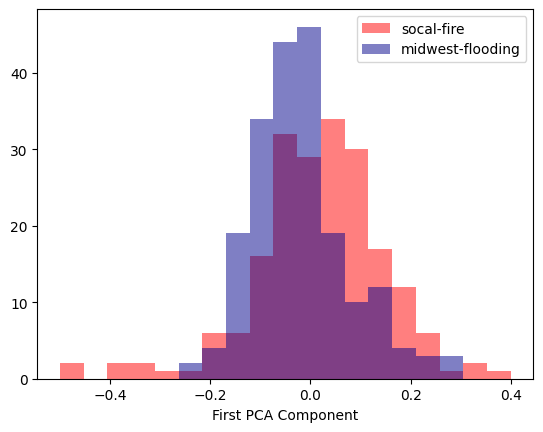

In [ ]:
bins = np.linspace(-0.5, 0.4, 20)
plt.hist(visualization[y=='socal-fire', 0], bins=bins, label='socal-fire', alpha=0.5, color='red')
plt.hist(visualization[y=='midwest-flooding', 0],  bins=bins, label='midwest-flooding', alpha=0.5, color='darkblue')
plt.xlabel("First PCA Component")
plt.legend()

There appears to be a small, secondary peak for very low PC1 values of Socal Fire. Let's take a look at the images that are in this bump.

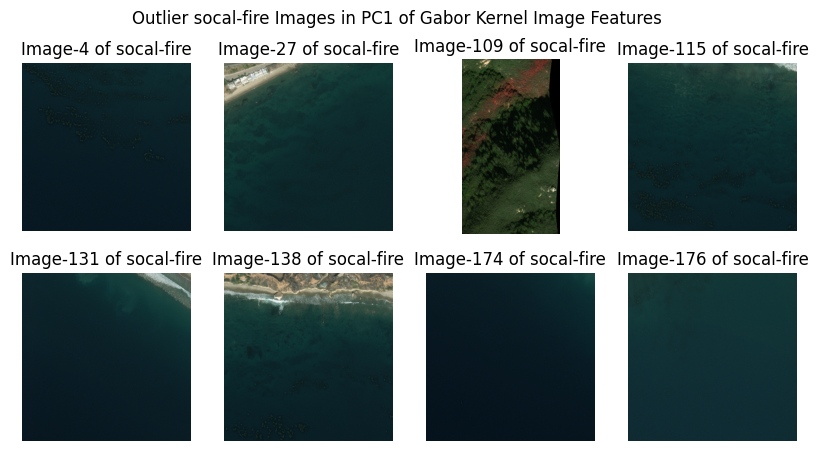

In [ ]:
outlier_image_idxs = np.argwhere((visualization[:, 0] < -0.2) & (y=='socal-fire')).flatten()
outlier_images = [ crop_image(data['socal-fire']['images'][i]) for i in outlier_image_idxs ]

fig, axes = plt.subplots(2, 4, figsize=(10,5))

fig.suptitle("Outlier socal-fire Images in PC1 of Gabor Kernel Image Features")

for ax, image, image_number in zip(axes.flatten(), outlier_images, outlier_image_idxs):
    ax.imshow(image)
    ax.set_title(f"Image-{image_number} of socal-fire")
    ax.axis("off")

Interesting! With the exception of Image-109, these are all images consisting mostly of the ocean. Perhaps we should attempt to identify these separately and filter them out first before developing our primary model. I suspect that a simple average color/variance check will be sufficient to do so reliably.

##### Conclusion - Gabor Kernels

Given the above histogram, it appears the features from gabor kernels can at least partially separate the images of fires vs. flooding. It also proved useful for identify outliers that I otherwise may not have noticed.

#### Local Binary Pattern

### 2. Damage levels 1 vs 3 within the `hurricane-matthew` dataset

Is there a relationship between the damage level and:

- image height, width, or overall size?
- RGB values?
- Sobel edges?
- Local Binary Patterns?
- Gabor kernels?